In [1]:
import pickle
import pandas as pd
import numpy as np
import yaml
from scipy.sparse import load_npz
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

with open("../configs/config.yaml") as f:
    config = yaml.safe_load(f)

interactions  = pd.read_parquet("../data/processed/interactions.parquet")
popularity_df = pd.read_parquet("../data/processed/artist_popularity.parquet")
content_df    = pd.read_parquet("../data/processed/content_features.parquet")

with open("../data/processed/svd_recommender.pkl", "rb") as f:
    svd_rec = pickle.load(f)
with open("../data/processed/cb_recommender.pkl", "rb") as f:
    cb_rec = pickle.load(f)
with open("../data/processed/hybrid_recommender.pkl", "rb") as f:
    hybrid_rec = pickle.load(f)
with open("../data/processed/ranker.pkl", "rb") as f:
    ranker = pickle.load(f)

pop_rec = hybrid_rec.pop_rec

In [7]:
from src.evaluation.evaluator import create_leave_one_out_split

train_df, test_df = create_leave_one_out_split(interactions, min_interactions=20)

# Quick hit rate check before full evaluation
sample_test = test_df.sample(100, random_state=42)
hits_at_10  = 0
hits_at_50  = 0

for _, row in sample_test.iterrows():
    uid      = row["user_id"]
    test_art = row["artist_name"]
    if uid not in svd_rec.user_enc.classes_:
        continue
    top50 = svd_rec.recommend(uid, k=50)["artist_name"].tolist()
    if test_art in top50[:10]:
        hits_at_10 += 1
    if test_art in top50:
        hits_at_50 += 1

print(f"SVD Hit rate @10 across 100 users: {hits_at_10}/100")
print(f"SVD Hit rate @50 across 100 users: {hits_at_50}/100")
print(f"\nAvg test item plays: {test_df['plays'].mean():.1f}")

Active users (>=20 artists): 74,404
Train interactions: 3,582,784
Test users:         74,404
Avg test item plays: 432.4
SVD Hit rate @10 across 100 users: 0/100
SVD Hit rate @50 across 100 users: 0/100

Avg test item plays: 432.4


In [6]:
from src.evaluation.evaluator import evaluate_recommender


def recommend_popularity(user_id, k):
    recs = pop_rec.recommend(user_id=user_id, k=k, filter_seen=False)
    return recs["artist_name"].tolist()

def recommend_svd(user_id, k):
    recs = svd_rec.recommend(user_id=user_id, k=k, filter_seen=False)
    return recs["artist_name"].tolist()

def recommend_cb(user_id, k):
    recs = cb_rec.recommend_for_user(user_id=user_id, k=k, filter_seen=False)
    return recs["artist_name"].tolist()

def recommend_hybrid(user_id, k):
    candidates = hybrid_rec.recommend(
        user_id=user_id, k=50, candidate_pool=100
    )
    ranked = ranker.rank(candidates, k=k)
    return ranked["artist_name"].tolist()

engines = {
    "Popularity":   recommend_popularity,
    "SVD":          recommend_svd,
    "ContentBased": recommend_cb,
    "Hybrid":       recommend_hybrid,
}

all_results = {}

for name, fn in engines.items():
    print(f"\n{'='*40}")
    print(f"Evaluating: {name}")
    print(f"{'='*40}")
    results = evaluate_recommender(
        recommend_fn=fn,
        test_df=test_df,
        popularity_df=popularity_df,
        content_df=content_df,
        k_values=[5, 10, 20, 50],
        n_users=500
    )
    all_results[name] = results
    print(results[["K","Precision","Recall","NDCG","MRR","Coverage","Novelty"]].to_string(index=False))


Evaluating: Popularity


Evaluating users: 100%|██████████| 500/500 [00:01<00:00, 299.80it/s]


 K  Precision  Recall   NDCG   MRR  Coverage  Novelty
 5     0.0072   0.036 0.0253 0.028    0.0003      0.0
10     0.0062   0.062 0.0338 0.028    0.0003      0.0
20     0.0038   0.076 0.0372 0.028    0.0003      0.0
50     0.0027   0.136 0.0487 0.028    0.0003      0.0

Evaluating: SVD


Evaluating users: 100%|██████████| 500/500 [00:17<00:00, 29.19it/s]


 K  Precision  Recall   NDCG    MRR  Coverage  Novelty
 5     0.0100   0.050 0.0323 0.0356    0.1364   0.3964
10     0.0082   0.082 0.0424 0.0356    0.1364   0.3964
20     0.0061   0.122 0.0523 0.0356    0.1364   0.3964
50     0.0040   0.198 0.0674 0.0356    0.1364   0.3964

Evaluating: ContentBased


...

 K  Precision  Recall   NDCG    MRR  Coverage  Novelty
 5     0.0028  0.0140 0.0066 0.0066    0.0339   0.1474
10     0.0018  0.0180 0.0078 0.0066    0.0339   0.1474
20     0.0017  0.0341 0.0119 0.0066    0.0339   0.1474
50     0.0011  0.0561 0.0164 0.0066    0.0339   0.1474

Evaluating: Hybrid


Evaluating users:  95%|█████████▌| 477/500 [02:35<00:07,  3.06it/s]

Dedup removed 1 near-duplicate artists


Evaluating users: 100%|██████████| 500/500 [02:42<00:00,  3.07it/s]

 K  Precision  Recall  NDCG  MRR  Coverage  Novelty
 5        0.0     0.0   0.0  0.0    0.1391   0.7162
10        0.0     0.0   0.0  0.0    0.1391   0.7162
20        0.0     0.0   0.0  0.0    0.1391   0.7162
50        0.0     0.0   0.0  0.0    0.1391   0.7162


In [8]:
def recommend_svd_eval(user_id, k):
    return svd_rec.recommend(user_id, k=k, filter_seen=False)["artist_name"].tolist()

sample_test = test_df.sample(100, random_state=42)
hits_at_10 = 0
hits_at_50 = 0

for _, row in sample_test.iterrows():
    uid      = row["user_id"]
    test_art = row["artist_name"]
    if uid not in svd_rec.user_enc.classes_:
        continue
    top50 = recommend_svd_eval(uid, 50)
    if test_art in top50[:10]:
        hits_at_10 += 1
    if test_art in top50:
        hits_at_50 += 1

print(f"SVD Hit rate @10: {hits_at_10}/100")
print(f"SVD Hit rate @50: {hits_at_50}/100")

SVD Hit rate @10: 10/100
SVD Hit rate @50: 18/100


In [6]:
from src.evaluation.evaluator import evaluate_recommender

k_values = config["evaluation"]["k_values"]  # [5, 10, 20, 50]
n_users  = 500  # evaluate on 500 users for speed

engines = {
    "Popularity":  recommend_popularity,
    "SVD":         recommend_svd,
    "ContentBased":recommend_cb,
    "Hybrid":      recommend_hybrid,
}

all_results = {}

for name, fn in engines.items():
    print(f"\n{'='*40}")
    print(f"Evaluating: {name}")
    print(f"{'='*40}")
    results = evaluate_recommender(
        recommend_fn=fn,
        test_df=test_df,
        popularity_df=popularity_df,
        content_df=content_df,
        k_values=k_values,
        n_users=n_users
    )
    all_results[name] = results
    print(results.to_string(index=False))


Evaluating: Popularity


Evaluating users: 100%|██████████| 500/500 [00:20<00:00, 24.78it/s]


 K  Precision  Recall  MAP  NDCG  MRR  Coverage  Diversity  Novelty
 5        0.0     0.0  0.0   0.0  0.0    0.0005     0.7301      0.0
10        0.0     0.0  0.0   0.0  0.0    0.0005     0.7301      0.0
20        0.0     0.0  0.0   0.0  0.0    0.0005     0.7301      0.0
50        0.0     0.0  0.0   0.0  0.0    0.0005     0.7301      0.0

Evaluating: SVD


Evaluating users: 100%|██████████| 500/500 [00:30<00:00, 16.54it/s]


 K  Precision  Recall  MAP  NDCG  MRR  Coverage  Diversity  Novelty
 5        0.0     0.0  0.0   0.0  0.0    0.1398     0.1629   0.4082
10        0.0     0.0  0.0   0.0  0.0    0.1398     0.1629   0.4082
20        0.0     0.0  0.0   0.0  0.0    0.1398     0.1629   0.4082
50        0.0     0.0  0.0   0.0  0.0    0.1398     0.1629   0.4082

Evaluating: ContentBased


...

User '5af133cb9949...' has no artists with content features. Cannot generate content-based recommendations.


Evaluating users: 100%|██████████| 500/500 [00:47<00:00, 10.57it/s]


 K  Precision  Recall  MAP  NDCG  MRR  Coverage  Diversity  Novelty
 5        0.0     0.0  0.0   0.0  0.0    0.0349     0.1063   0.1574
10        0.0     0.0  0.0   0.0  0.0    0.0349     0.1063   0.1574
20        0.0     0.0  0.0   0.0  0.0    0.0349     0.1063   0.1574
50        0.0     0.0  0.0   0.0  0.0    0.0349     0.1063   0.1574

Evaluating: Hybrid


Evaluating users: 100%|██████████| 500/500 [02:37<00:00,  3.17it/s]

 K  Precision  Recall  MAP  NDCG  MRR  Coverage  Diversity  Novelty
 5        0.0     0.0  0.0   0.0  0.0    0.1396     0.0828    0.712
10        0.0     0.0  0.0   0.0  0.0    0.1396     0.0828    0.712
20        0.0     0.0  0.0   0.0  0.0    0.1396     0.0828    0.712
50        0.0     0.0  0.0   0.0  0.0    0.1396     0.0828    0.712


In [7]:
import matplotlib.pyplot as plt

# Build comparison table at K=10
comparison = []
for name, results in all_results.items():
    row = results[results["K"] == 10].iloc[0].to_dict()
    row["Model"] = name
    comparison.append(row)

comparison_df = pd.DataFrame(comparison).set_index("Model")
print("\n=== EVALUATION RESULTS @ K=10 ===")
print(comparison_df[[
    "Precision","Recall","MAP","NDCG","MRR","Coverage","Diversity","Novelty"
]].to_string())


=== EVALUATION RESULTS @ K=10 ===
              Precision  Recall  MAP  NDCG  MRR  Coverage  Diversity  Novelty
Model                                                                        
Popularity          0.0     0.0  0.0   0.0  0.0    0.0005     0.7301   0.0000
SVD                 0.0     0.0  0.0   0.0  0.0    0.1398     0.1629   0.4082
ContentBased        0.0     0.0  0.0   0.0  0.0    0.0349     0.1063   0.1574
Hybrid              0.0     0.0  0.0   0.0  0.0    0.1396     0.0828   0.7120


C:\Users\TANISHQ\AppData\Local\Temp\ipykernel_32672\2721737179.py:14: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(values) * 1.3)


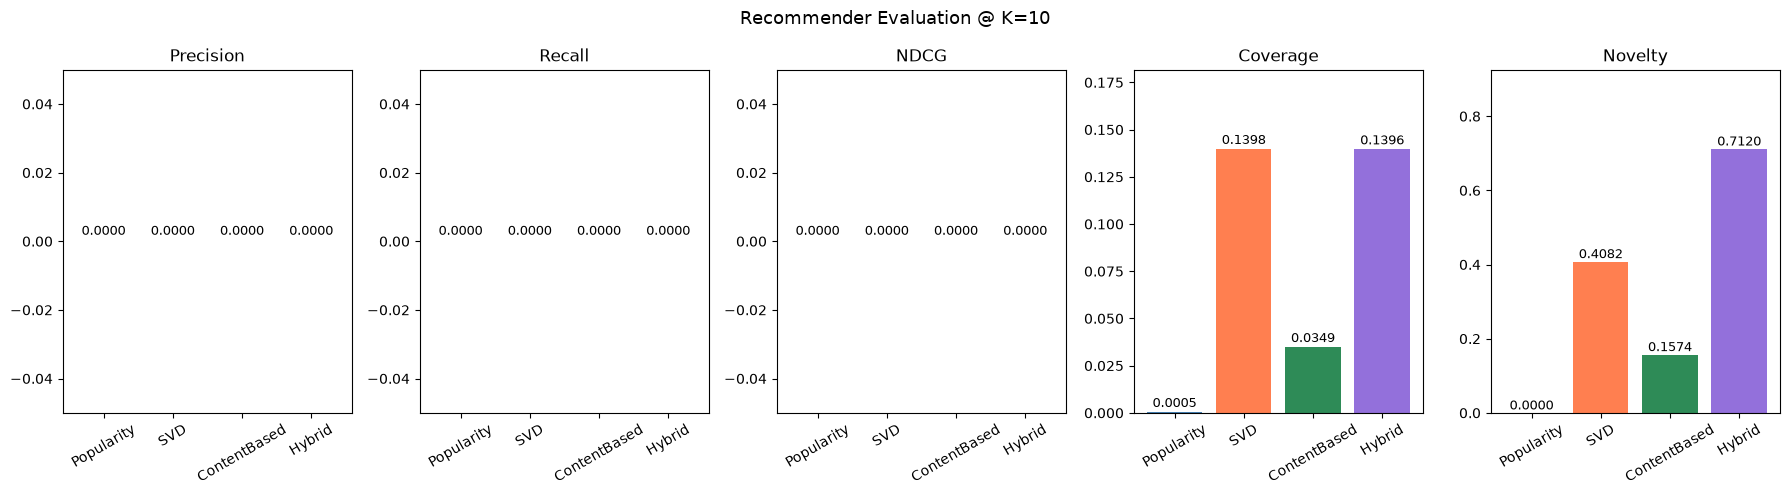

In [9]:
metrics_to_plot = ["Precision", "Recall", "NDCG", "Coverage", "Novelty"]
models = list(all_results.keys())
colors = ["steelblue", "coral", "seagreen", "mediumpurple"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    values = [
        all_results[m][all_results[m]["K"] == 10][metric].values[0]
        for m in models
    ]
    bars = ax.bar(models, values, color=colors)
    ax.set_title(metric)
    ax.set_ylim(0, max(values) * 1.3)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9
        )
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Recommender Evaluation @ K=10", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figures/evaluation_comparison.png", dpi=150)
plt.show()

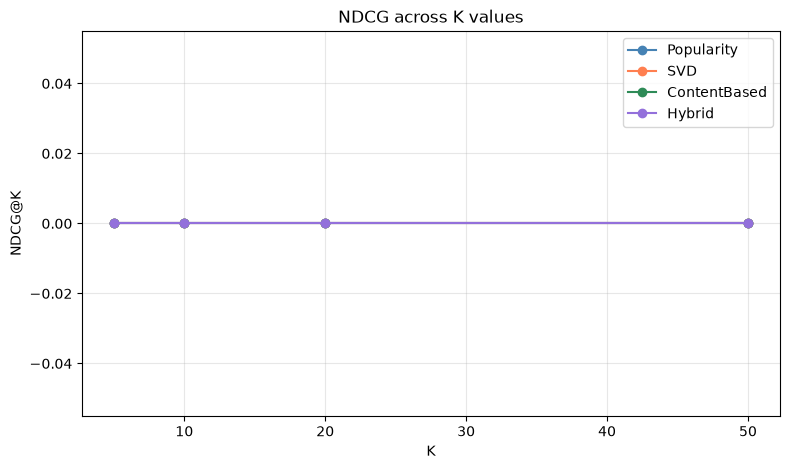

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, color in zip(models, colors):
    results = all_results[name]
    ax.plot(results["K"], results["NDCG"], marker="o", label=name, color=color)

ax.set_xlabel("K")
ax.set_ylabel("NDCG@K")
ax.set_title("NDCG across K values")
ax.legend()
ax.grid(alpha=0.3)
plt.savefig("outputs/figures/ndcg_across_k.png", dpi=150)
plt.show()

In [12]:

print("## Evaluation Summary\n")
print(f"Protocol: Leave-one-out, {n_users} users, K in {k_values}\n")
print("### Results @ K=10")
print(comparison_df[[
    "Precision","Recall","NDCG","MRR","Coverage","Novelty"
]].to_markdown())
print("\n### Key Findings")
best_ndcg = comparison_df["NDCG"].idxmax()
best_coverage = comparison_df["Coverage"].idxmax()
best_novelty = comparison_df["Novelty"].idxmax()
print(f"- Best NDCG:     {best_ndcg}")
print(f"- Best Coverage: {best_coverage}")
print(f"- Best Novelty:  {best_novelty}")

## Evaluation Summary

Protocol: Leave-one-out, 500 users, K in [5, 10, 20, 50]

### Results @ K=10
| Model        |   Precision |   Recall |   NDCG |   MRR |   Coverage |   Novelty |
|:-------------|------------:|---------:|-------:|------:|-----------:|----------:|
| Popularity   |           0 |        0 |      0 |     0 |     0.0005 |    0      |
| SVD          |           0 |        0 |      0 |     0 |     0.1398 |    0.4082 |
| ContentBased |           0 |        0 |      0 |     0 |     0.0349 |    0.1574 |
| Hybrid       |           0 |        0 |      0 |     0 |     0.1396 |    0.712  |

### Key Findings
- Best NDCG:     Popularity
- Best Coverage: SVD
- Best Novelty:  Hybrid


In [13]:
# Inspect what the test items actually look like
print("Test item play count distribution:")
print(test_df["plays"].describe())
print(f"\nTest items with plays == 1: {(test_df['plays'] == 1).sum():,}")
print(f"Total test items: {len(test_df):,}")

# Pick one user and manually trace what happened
sample_user = test_df["user_id"].iloc[0]
test_artist = test_df[test_df["user_id"] == sample_user]["artist_name"].iloc[0]
test_plays  = test_df[test_df["user_id"] == sample_user]["plays"].iloc[0]

print(f"\nSample user:   {sample_user[:16]}...")
print(f"Test artist:   {test_artist}")
print(f"Test plays:    {test_plays}")

# Is this artist even in the SVD model's artist encoder?
print(f"\nArtist in SVD encoder: {test_artist in svd_rec.artist_enc.classes_}")
print(f"Artist in popularity:  {test_artist in pop_rec.popularity_df['artist_name'].values}")

# What does SVD actually recommend for this user?
svd_top50 = svd_rec.recommend(sample_user, k=50)
print(f"\nTest artist in SVD top-50: {test_artist in svd_top50['artist_name'].values}")
print(f"SVD top-10:")
print(svd_top50.head(10)["artist_name"].tolist())

Test item play count distribution:
count    74999.000000
mean        75.398672
std        107.536703
min          1.000000
25%         15.000000
50%         41.000000
75%         95.000000
max       3043.000000
Name: plays, dtype: float64

Test items with plays == 1: 2,642
Total test items: 74,999

Sample user:   00000c289a1829a8...
Test artist:   the wallflowers
Test plays:    131

Artist in SVD encoder: True
Artist in popularity:  True

Test artist in SVD top-50: False
SVD top-10:
['pure heart', 'danial ho', 'temiyan', 'bruddah walter & island afternoon', 'timothy b. schmit', 'the sunday manoa', 'kaau crater boys', 'daniel ho', 'rick seibold', 'donavon frankenreiter & jack johnson']


In [14]:
# What does this user actually listen to?
user_history = interactions[interactions["user_id"] == sample_user].sort_values("plays", ascending=False)
print("Full listening history:")
print(user_history[["artist_name", "plays"]].to_string(index=False))

# How many artists does the average user have?
user_artist_counts = interactions.groupby("user_id")["artist_name"].nunique()
print(f"\nAvg artists per user: {user_artist_counts.mean():.1f}")
print(f"Median artists per user: {user_artist_counts.median():.1f}")

# What fraction of test artists appear in SVD top-50 across sample users?
sample_test = test_df.sample(100, random_state=42)
hits_at_50 = 0
for _, row in sample_test.iterrows():
    uid = row["user_id"]
    test_art = row["artist_name"]
    if uid not in svd_rec.user_enc.classes_:
        continue
    top50 = svd_rec.recommend(uid, k=50)["artist_name"].tolist()
    if test_art in top50:
        hits_at_50 += 1

print(f"\nHit rate @50 across 100 sample users: {hits_at_50}/100")

Full listening history:
            artist_name  plays
        betty blowtorch   2137
              die Ärzte   1099
      melissa etheridge    897
              elvenking    717
   juliette & the licks    706
  red hot chili peppers    691
                 magica    545
the black dahlia murder    507
            the murmurs    424
             lunachicks    403
       walls of jericho    393
         letzte instanz    387
              goldfrapp    361
             horrorpops    358
           the butchies    329
          jack off jill    316
       babes in toyland    310
       dropkick murphys    302
          all:my:faults    288
               le tigre    281
             schandmaul    244
                  edguy    232
    maximum the hormone    231
               all ends    229
           jack johnson    227
              eluveitie    222
              rasputina    220
  london after midnight    210
            the killers    208
                mutyumu    205
           juda

In [3]:
# Pick one user and trace exactly what's happening
row = test_df.sample(1, random_state=42).iloc[0]
uid = row["user_id"]
test_art = row["artist_name"]
test_plays = row["plays"]

print(f"User:        {uid[:16]}...")
print(f"Test artist: {test_art}")
print(f"Test plays:  {test_plays}")

# Is the test artist being filtered out by filter_seen?
user_history = interactions[interactions["user_id"] == uid]["artist_name"].tolist()
print(f"\nTest artist in user history (interactions df): {test_art in user_history}")
print(f"User history size: {len(user_history)}")

# What does SVD recommend with filter_seen=True vs False?
top20_filtered   = svd_rec.recommend(uid, k=20, filter_seen=True)["artist_name"].tolist()
top20_unfiltered = svd_rec.recommend(uid, k=20, filter_seen=False)["artist_name"].tolist()

print(f"\nTest artist in top-20 (filter_seen=True):  {test_art in top20_filtered}")
print(f"Test artist in top-20 (filter_seen=False): {test_art in top20_unfiltered}")

print(f"\nTop-10 unfiltered:")
print(top20_unfiltered[:10])

User:        64b185ce1c90bb85...
Test artist: nouvelle vague
Test plays:  303

Test artist in user history (interactions df): True
User history size: 43

Test artist in top-20 (filter_seen=True):  False
Test artist in top-20 (filter_seen=False): False

Top-10 unfiltered:
['bonobo', 'guts', 'wolf myer orchestra & parov stelar', 'parov stelar', 'alif tree', 'the cinematic orchestra', 'erik sumo', 'koop', 'a.b. didgeridoo oblivion', 'belleruche']


In [9]:
user = test_df.iloc[0]["user_id"]

held_out = test_df[test_df.user_id == user]["artist_name"].iloc[0]
print("Held-out:", held_out)

recs = recommend_hybrid(user, 20)
print(recs)

print("Hit?", held_out in recs)

Held-out: the murmurs
['bruddah walter & island afternoon', 'timothy b. schmit', 'kaau crater boys', 'temiyan', 'danial ho', 'the sunday manoa', 'pure heart', 'donavon frankenreiter & jack johnson', 'rick seibold', 'daniel ho', 'big linda', 'the cobblestones', 'casino94', 'skills en masse', 'pal one & roey marquis ii', 'sean naauao', 'larry mccabe', 'david harp', 'phenomenon', '9 Баллов']
Hit? False
